# Propagation of Soliton Solutions of the Nonlinear Schrödinger Equation

The program propagates soliton solutions of the nonlinear Schrödinger equation. Both analytical solutions are shown and the differential equation is solved numerically using the finite-difference method.

## Nonlinear Schrödinger Equation

The simulated equation is

\begin{equation}
i\frac{\partial \psi}{\partial t} + \frac{\partial^2 \psi}{\partial x^2} + 2g |\psi|^2 \psi = 0
\end{equation}

The analytical fundamental soliton solution used in the program is

\begin{equation}
\psi(x,t) = A_0 \, \mathrm{sech}\left(\frac{t-x/v}{t_0}\right) e^{-i x/x_0}
\end{equation}

The equation is solved numerically with a finite-difference method.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

### Analytical Soliton Solution

In [2]:
def sech(x):
    return 1/np.cosh(x)

# analytical solution of a soliton of the first type (fundamental solution) in the nonlinear Schrödinger equation
def NLSGSoliton1(x,t,A0,v,t0,x0,NG):
    y = A0 * sech((t - x[:NG]/v)/t0) * np.exp(-1j*x[:NG]/x0)
    return y

## Parameters

In [3]:
L = 80                               # Length of the grid

NG = 801                             # Number of spatial grid points
dx = L/(NG-1)                        # Distance between two grid points
x = -L/4 + np.arange(NG)*dx
                
Tmax = 20.                           # maximum time
NT = 100001                          # steps in time
dt = Tmax/(NT-1)                     # time step
t = np.arange(NT)*dt                 # time grid

## Soliton of the Fundamental Type

### Prepare Grid

In [4]:
y1 = np.zeros((NT,NG),dtype=complex)

### Initial Conditions

In [5]:
# Initial condition: soliton with velocity v
vr = 1.5
gr = 0.8

# Set parameters for the calculation
v  = vr
g  = gr
x0 = -1./v
t0 = 1./v**2
A0 = v/np.sqrt(g)

y1[0,:] = NLSGSoliton1(x,0,A0,v,t0,x0,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y1[1,:] = NLSGSoliton1(x,dt,A0,v,t0,x0,NG)

## Solution of the Differential Equation

### Finite Difference Scheme

Second spatial derivative

\begin{equation}
\psi_{xx} \approx \psi_{i+1}+\psi_{i-1}-2\psi_i
\end{equation}

Time stepping scheme

\begin{equation}
\psi_j = \psi_{j-2} + i\frac{dt}{dx^2}\psi_{xx} + 2i dt g |\psi|^2 \psi
\end{equation}

In [6]:
# Solve the differential equation using the finite-difference method
for j in range(2,NT):

    yx2 = y1[j-1,3:NG] + y1[j-1,1:NG-2] - 2*y1[j-1,2:NG-1]

    y1[j,2:NG-1] = (
        y1[j-2,2:NG-1]
        + 1j*dt/dx**2 * yx2
        + 2j*dt*g*np.abs(y1[j-1,2:NG-1])**2 * y1[j-1,2:NG-1])

## Visualization

### Variation of Parameters

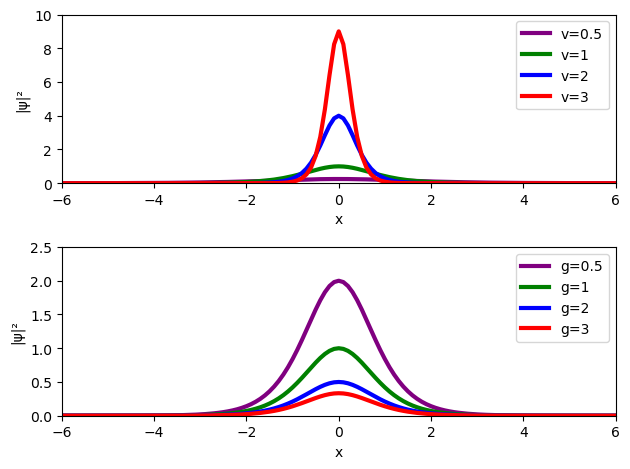

In [7]:
Colors = ['purple','green','blue','red']

plt.figure()

plt.subplot(2,1,1)

v=0.5; g=1.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[0])

v=1.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[1])

v=2.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[2])

v=3.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[3])

plt.axis([-6,6,0,10])
plt.xlabel('x')
plt.ylabel('|ψ|²')
plt.legend(['v=0.5','v=1','v=2','v=3'])


# Plot showing the variation of g
plt.subplot(2,1,2)

v=1; g=0.5
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[0])

g=1.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[1])

g=2.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[2])

g=3.
plt.plot(x,np.abs(NLSGSoliton1(x,0,v/np.sqrt(g),v,1./v**2,-1./v,NG))**2,
         linewidth=3,color=Colors[3])

plt.axis([-6,6,0,2.5])
plt.xlabel('x')
plt.ylabel('|ψ|²')
plt.legend(['g=0.5','g=1','g=2','g=3'])

plt.tight_layout()

### Visualization Numerical Solution (Moving Solitons)

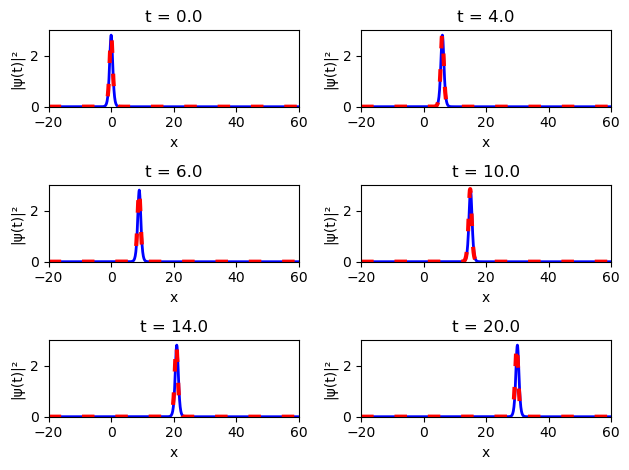

In [16]:
k = [0,19999,29999,49999,69999,100000]

plt.figure()

for idx,i in enumerate(k):

    plt.subplot(3,2,idx+1)

    plt.plot(x,
             np.abs(NLSGSoliton1(x,dt*(i),A0,vr,t0,x0,NG))**2,
             linewidth=2,color='blue')

    line, = plt.plot(x,
                     np.abs(y1[i,:])**2,
                     linewidth=3,color='red')

    line.set_dashes([3,5])

    plt.axis([np.min(x),np.max(x),0,3])
    plt.xlabel('x')
    plt.ylabel('|ψ(t)|²')

    titletext = f"t = {t[i]:.1f}"
    plt.title(titletext)

plt.tight_layout()
plt.show()